# Quantum Broadcasting Protocol

Unified implementation notebook supporting three execution modes:

| Mode | Backend | Description |
|------|---------|-------------|
| **Exact** | `ExactBackend` | Full density-matrix simulation (no sampling noise) |
| **Sampling** | `SamplingBackend` | Monte Carlo Pauli-trajectory simulation |
| **Hardware** | `HardwareBackend` | Run on IBM Quantum hardware via `qiskit-ibm-runtime` |

Select the mode in **Cell 2** and run all cells.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from broadcasting.protocol import ProtocolConfig, BroadcastResult
from broadcasting.backend import ExactBackend, SamplingBackend, HardwareBackend
from broadcasting.results import save_run, load_run, list_runs
from broadcasting.plotting import (
    plot_fidelity_vs_noise,
    plot_fidelity_vs_delay,
    plot_3d_fidelity,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120})

## 1. Configuration

Set protocol parameters and choose a mode.

In [2]:
# ---------- Choose mode ----------
MODE = "sampling"  # "exact" | "sampling" | "hardware"

# ---------- Protocol parameters ----------
M = 1                          # senders
N = 2                          # receivers
alpha = 1.0 / np.sqrt(2)  # input-state coefficient
thetas = np.random.rand(M) * 2 * np.pi  # sender phase angles
outcomes = [0] * M             # Alice measurement outcomes
use_qec = True                # enable [[5,1,3]] QEC

# Noise sweep
p_list = np.linspace(0, 1, 50).tolist()

# Sampling-mode options
n_samples = 1000
seed = 42

# Hardware-mode options (fill in when MODE="hardware")
IBM_CHANNEL = "ibm_quantum"      # or "ibm_cloud"
IBM_INSTANCE = "ibm-q/open/main"
IBM_BACKEND  = "ibm_brisbane"    # can check least busy with service.least_busy(simulator=False, operational=True)
SHOTS = 4096

print(f"Mode: {MODE}  |  M={M}, N={N}, QEC={use_qec}  |  {len(p_list)} noise values")

Mode: sampling  |  M=1, N=2, QEC=True  |  50 noise values


## 2. Run Experiment

In [3]:
config = ProtocolConfig(
    M=M, N=N, alpha=alpha, thetas=thetas,
    p_list=p_list, use_qec=use_qec,
    outcomes_list=outcomes,
    n_samples=n_samples if MODE == "sampling" else None,
    seed=seed,
)

if MODE == "exact":
    backend = ExactBackend()
elif MODE == "sampling":
    backend = SamplingBackend(n_samples=n_samples, seed=seed)
elif MODE == "hardware":
    from qiskit_ibm_runtime import QiskitRuntimeService
    service = QiskitRuntimeService(channel=IBM_CHANNEL, instance=IBM_INSTANCE)
    backend = HardwareBackend(service=service, backend_name=IBM_BACKEND, shots=SHOTS)
else:
    raise ValueError(f"Unknown mode: {MODE}")

result = backend.run(config)
print(f"Fidelities shape: {np.array(result.fidelities).shape}")
print(f"Mode recorded:    {result.metadata.get('mode')}")

Fidelities shape: (50, 2)
Mode recorded:    sampled (1000 trajectories)


## 3. Save Results

In [4]:
out_path = save_run(result, config)
print(f"Saved to {out_path}")

Saved to results/run_20260416_100341.json


## 4. Plot: Fidelity vs Noise

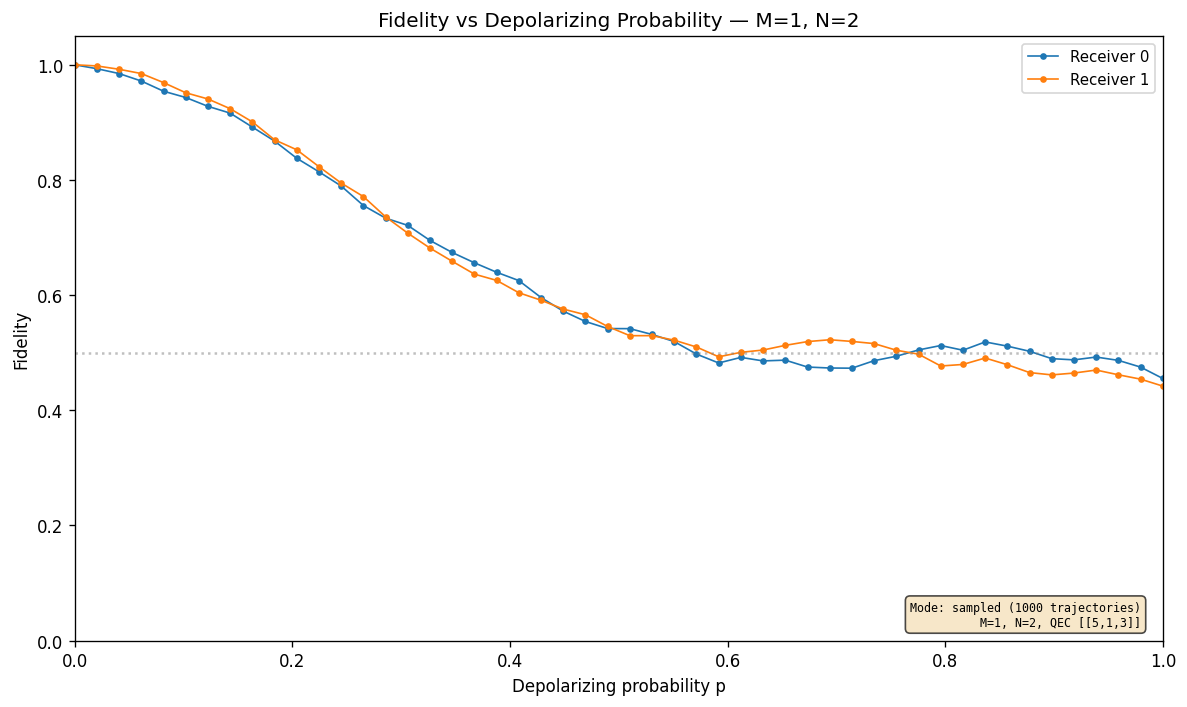

In [5]:
fids = np.array(result.fidelities)  # shape (len(p_list), N)
fidelity_arrays = {f"Receiver {i}": fids[:, i] for i in range(N)}

plot_fidelity_vs_noise(
    np.array(p_list),
    fidelity_arrays,
    mode_label=result.metadata.get("mode", MODE),
    protocol_info={"M": M, "N": N, "use_qec": use_qec},
    title=f"Fidelity vs Depolarizing Probability — M={M}, N={N}",
);

## 5. Compare Exact vs Sampling (optional)

Run both backends and overlay the curves.

In [ ]:
# Uncomment to run the comparison
exact_result   = ExactBackend().run(config)
sampling_result = SamplingBackend(n_samples=5000, seed=0).run(
    config._replace(use_qec=False) if hasattr(config, '_replace')
    else ProtocolConfig(**{**config.__dict__, 'use_qec': False})
)

fig, ax = plt.subplots(figsize=(10, 6))
p_arr = np.array(p_list)
exact_fids = np.array(exact_result.fidelities)
samp_fids  = np.array(sampling_result.fidelities)
for i in range(N):
    ax.plot(p_arr, exact_fids[:, i], '-', label=f'Exact R{i}')
    ax.plot(p_arr, samp_fids[:, i], '--', label=f'Sampling R{i}')
ax.set_xlabel('p'); ax.set_ylabel('Fidelity')
ax.legend(); ax.set_title('Exact vs Sampling comparison')
plt.tight_layout(); plt.show()

## 6. Load & Inspect Previous Runs

In [ ]:
runs = list_runs()
print(f"{len(runs)} saved runs:")
for r in runs[-5:]:
    print(f"  {r.name}")

## 7. Sampling Convergence Analysis

Quantify how the `SamplingBackend` converges to the exact result as the
number of Monte Carlo trajectories `n_samples` grows.

For the fixed scenario **M=1, N=2, QEC=on** we:

1. Compute (or reuse) the exact fidelity curve over `p_list`.
2. For each `n_samples` in a sweep, run the sampling backend.
3. Define the per-receiver error as the area between the sampled and
   exact fidelity curves (trapezoid rule over `p`).
4. Plot total error (summed over receivers) vs `n_samples`.

In [3]:
# Fixed scenario for convergence study
CONV_M, CONV_N = 1, 2
CONV_USE_QEC = True
CONV_ALPHA = 1.0 / np.sqrt(2)
CONV_THETAS = np.zeros(CONV_M)           # deterministic for reproducibility
CONV_OUTCOMES = [0] * CONV_M
CONV_P_LIST = np.linspace(0, 1, 21).tolist()
CONV_SEED = 0

conv_config_exact = ProtocolConfig(
    M=CONV_M, N=CONV_N, alpha=CONV_ALPHA, thetas=CONV_THETAS,
    p_list=CONV_P_LIST, use_qec=CONV_USE_QEC,
    outcomes_list=CONV_OUTCOMES, seed=CONV_SEED,
)

# Try to reuse a matching exact run; otherwise compute it.
def _matches_exact(run_path):
    try:
        r = load_run(run_path)
    except Exception:
        return False
    meta = getattr(r, "metadata", {}) or {}
    return (
        str(meta.get("mode", "")).lower() == "exact"
        and meta.get("M") == CONV_M
        and meta.get("N") == CONV_N
        and bool(meta.get("use_qec")) == CONV_USE_QEC
        and list(meta.get("p_list", [])) == CONV_P_LIST
    )

reused = next((p for p in reversed(list_runs()) if _matches_exact(p)), None)
if reused is not None:
    print(f"Reusing exact run: {reused.name}")
    exact_conv = load_run(reused)
else:
    print("No matching exact run found; computing now...")
    exact_conv = ExactBackend().run(conv_config_exact)
    save_run(exact_conv, conv_config_exact)

exact_fids = np.array(exact_conv.fidelities)  # shape (len(p_list), N)
print(f"Exact fidelities shape: {exact_fids.shape}")

No matching exact run found; computing now...
Exact fidelities shape: (21, 2)


In [7]:
# Sweep over number of samples
n_samples_sweep = [50, 100, 200, 500, 1000, 2000, 5000, 10000, 50000, 100000]

p_arr = np.array(CONV_P_LIST)
errors_per_receiver = []   # list of arrays, shape (N,)
sampling_results = []

for ns in n_samples_sweep:
    cfg = ProtocolConfig(
        M=CONV_M, N=CONV_N, alpha=CONV_ALPHA, thetas=CONV_THETAS,
        p_list=CONV_P_LIST, use_qec=CONV_USE_QEC,
        outcomes_list=CONV_OUTCOMES,
        n_samples=ns, seed=CONV_SEED,
    )
    res = SamplingBackend(n_samples=ns, seed=CONV_SEED).run(cfg)
    samp_fids = np.array(res.fidelities)  # (len(p), N)
    # Area between curves per receiver (trapezoid over p)
    diff = np.abs(samp_fids - exact_fids)
    err = np.trapz(diff, p_arr, axis=0)   # shape (N,)
    errors_per_receiver.append(err)
    sampling_results.append(samp_fids)
    print(f"n_samples={ns:>6d}  per-receiver error={err}  total={err.sum():.4f}")

errors_per_receiver = np.array(errors_per_receiver)  # (len(sweep), N)
total_error = errors_per_receiver.sum(axis=1)

/tmp/ipykernel_8348/1669156713.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  err = np.trapz(diff, p_arr, axis=0)   # shape (N,)


n_samples=    50  per-receiver error=[0.05112242 0.06406069]  total=0.1152
n_samples=   100  per-receiver error=[0.03360319 0.04570696]  total=0.0793
n_samples=   200  per-receiver error=[0.01823954 0.02867114]  total=0.0469
n_samples=   500  per-receiver error=[0.01380007 0.01530059]  total=0.0291
n_samples=  1000  per-receiver error=[0.00854257 0.00830293]  total=0.0168
n_samples=  2000  per-receiver error=[0.00712716 0.00658012]  total=0.0137
n_samples=  5000  per-receiver error=[0.00434473 0.00502932]  total=0.0094
n_samples= 10000  per-receiver error=[0.00389442 0.00390928]  total=0.0078
n_samples= 50000  per-receiver error=[0.00184828 0.00165912]  total=0.0035
n_samples=100000  per-receiver error=[0.00127751 0.00120541]  total=0.0025


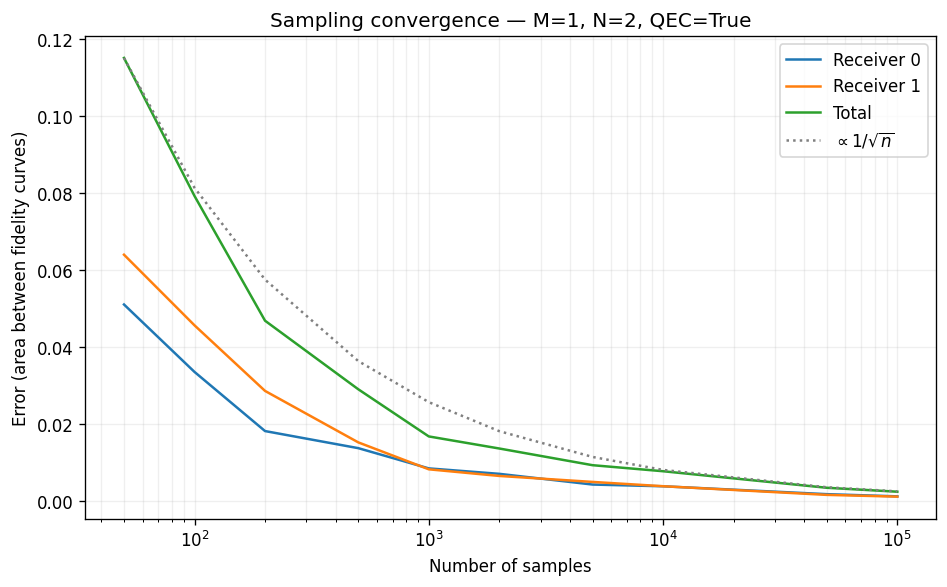

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for i in range(CONV_N):
    ax.semilogx(n_samples_sweep, errors_per_receiver[:, i], label=f'Receiver {i}')
ax.semilogx(n_samples_sweep, total_error, label='Total')

# 1/sqrt(n) reference, anchored to the first point
ref = total_error[0] * np.sqrt(n_samples_sweep[0]) / np.sqrt(n_samples_sweep)
ax.semilogx(n_samples_sweep, ref, ':', color='gray', label=r'$\propto 1/\sqrt{n}$')

ax.set_xlabel('Number of samples')
ax.set_ylabel('Error (area between fidelity curves)')
ax.set_title(f'Sampling convergence — M={CONV_M}, N={CONV_N}, QEC={CONV_USE_QEC}')
ax.grid(True, which='both', alpha=0.2)
ax.legend()
plt.tight_layout(); plt.show()

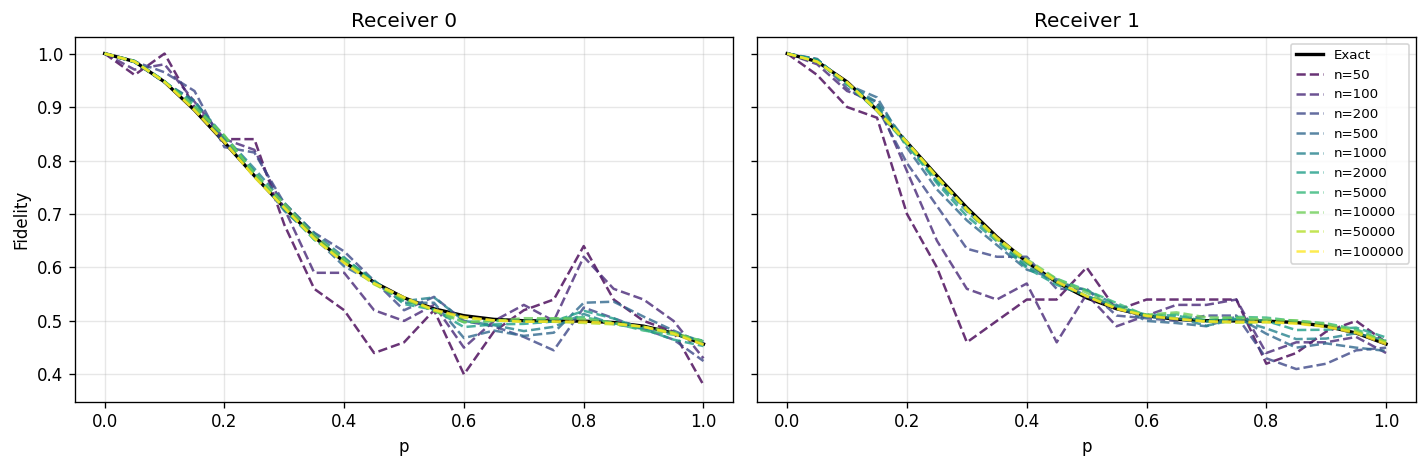

In [9]:
# Optional: visualize sampled vs exact fidelity curves for each n_samples
fig, axes = plt.subplots(1, CONV_N, figsize=(6 * CONV_N, 4), sharey=True)
if CONV_N == 1:
    axes = [axes]
cmap = plt.cm.viridis(np.linspace(0, 1, len(n_samples_sweep)))
for i, ax in enumerate(axes):
    ax.plot(p_arr, exact_fids[:, i], 'k-', lw=2, label='Exact')
    for k, ns in enumerate(n_samples_sweep):
        ax.plot(p_arr, sampling_results[k][:, i], '--',
                color=cmap[k], alpha=0.8, label=f'n={ns}')
    ax.set_xlabel('p'); ax.set_title(f'Receiver {i}')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Fidelity')
axes[-1].legend(fontsize=8, loc='best')
plt.tight_layout(); plt.show()